# Experiment 3 — TimeGAN Sample-Size Saturation Study

**Question:** for each QUIDA dataset, how many samples can one trained TimeGAN generate before extra samples
stop adding value (fidelity plateaus and the generator begins repeating itself)?

**Method (no self-consuming loop).** For each dataset and each random seed: train the TimeGAN **once** on the
real training split, then **generate at increasing sizes** (1x, 2x, 3x, 5x, 8x the real count) from that
single fixed model. Every generated set is scored against the same real reference. Results are **averaged
over seeds** so the recommended size is a stable knee, not an artifact of one split.

**Metrics:** MMD, Wasserstein, Correlation Difference, OCSVM coverage gap + Score Gap, Variance Increase,
and Density/Coverage (precision-recall for generative models). Distribution/geometry metrics are computed
in a shared standardized-PCA embedding of the real data; per-channel metrics (Wasserstein, correlation)
in standardized original space.

**Output:** per-dataset metric-vs-size tables and curves (knee marked), PCA overlays across sizes, and a
recommended sample size per dataset, plus a cross-dataset summary.

> This is the TimeGAN counterpart of Experiment 2 (Beta-VAE). Same sweep, same metrics, same visuals,
> same recommendation logic and the same reversible `Prep` pipeline — only the generator differs. Outputs
> go to `timegan_size_study/` so the two studies sit side by side for the planned VAE-vs-TimeGAN comparison
> (`cross_dataset_summary.csv` has matching columns).

> Note: a fixed TimeGAN does not lose per-sample quality as you draw more; what saturates is the *marginal
> value* of each extra sample. So the deliverable is a **saturation point**, not a cliff.

## 1. Import libraries

In [1]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

_saving = getattr(keras, "saving", None)
def _pick(fn): return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object   = _pick("serialize_keras_object")
deserialize_keras_object = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__,
      "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

2026-08-14 18:50:25.624968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786733425.645099   27306 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786733425.651126   27306 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786733425.666440   27306 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786733425.666466   27306 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786733425.666468   27306 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.1 | Keras: 3.10.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
@dataclass
class Config:
    # Dataset provided by the professor in Vocareum
    data_dir: Path = field(
        default_factory=lambda: (Path.cwd() / "../../data/data_zain/Dataset").resolve()
    )

    # Generated results stay inside the current EXP_3 directory
    output_dir: Path = field(
        default_factory=lambda: Path.cwd() / "timegan_size_study"
    )

    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = None

    seed: int = 42
    val_split: float = 0.2

    # --- sample-size sweep ---
    multipliers: tuple = (1, 2, 3, 5, 6, 7, 8, 9, 10)
    n_seeds: int = 3
    recommend_tol: float = 0.05

    # --- preprocessing (reversible, shared with the VAE study) ---
    use_signed_log: bool = True
    drop_constant: bool = True
    const_eps: float = 1e-8
    use_pca: bool = True
    pca_components: int = 32

    # --- model (TimeGAN: 5 GRU nets) ---
    hidden_dim: int = 24
    num_layers: int = 3
    gamma: float = 1.0

    # --- training ---
    embedding_epochs: int = 200
    supervised_epochs: int = 150
    joint_epochs: int = 250
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 30

    # --- evaluation ---
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150
    mmd_cap: int = 800
    pca_plot: bool = True


CFG = Config()

CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Data:", CFG.data_dir)
print("Output:", CFG.output_dir)
print(
    "Multipliers:", CFG.multipliers,
    "| seeds:", CFG.n_seeds
)

Data: /voc/data/data_zain/Dataset
Output: /voc/work/exp_3/timegan_size_study
Multipliers: (1, 2, 3, 5, 6, 7, 8, 9, 10) | seeds: 3


In [3]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed)
    try: keras.utils.set_random_seed(seed)
    except Exception: tf.random.set_seed(seed)
set_seeds(CFG.seed)

## 3. Load the four datasets

In [4]:
def _clean_name(fn):
    s = Path(fn).stem; return s[:-4] if s.endswith("_raw") else s

def discover_datasets(cfg):
    if cfg.datasets:
        items = list(cfg.datasets.items())
        miss = [str(cfg.data_dir/f) for _,f in items if not (cfg.data_dir/f).exists()]
        if miss: raise FileNotFoundError("Missing: " + ", ".join(miss))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q:(q.name.count("_"), q.name))
        if not files: raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data={}
    for name,fname in items:
        data[name]=np.load(cfg.data_dir/fname, allow_pickle=False).astype(np.float32)
        print(f"  {name:16s} <- {fname:26s} {data[name].shape}")
    return data
RAW = discover_datasets(CFG)

  X_imu            <- X_imu_raw.npy              (99, 32, 3)
  X_imu_ir         <- X_imu_ir_raw.npy           (99, 32, 771)
  X_imu_radar      <- X_imu_radar_raw.npy        (99, 32, 1137)
  X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     (99, 32, 1905)


## 4. Data validation

In [5]:
def validate_dataset(name, X, cfg):
    assert X.ndim==3, f"{name}: need (N,T,F), got {X.shape}"
    N,T,F=X.shape
    n_nan,n_inf=int(np.isnan(X).sum()),int(np.isinf(X).sum())
    if n_nan or n_inf:
        X=np.where(np.isfinite(X),X,np.nan)
        fm=np.nan_to_num(np.nanmean(X.reshape(-1,F),axis=0)); ii=np.where(~np.isfinite(X)); X[ii]=np.take(fm,ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst=int((np.ptp(X.reshape(-1,F).astype(np.float64),axis=0)<=cfg.const_eps).sum())
    print(f"  {name:16s} N={N} T={T} F={F} const_cols={nconst} min={X.min():+.1f} max={X.max():+.1f}")
    return X.astype(np.float32)
RAW={n:validate_dataset(n,X,CFG) for n,X in RAW.items()}

  X_imu            N=99 T=32 F=3 const_cols=0 min=-73.4 max=+72.1
  X_imu_ir         N=99 T=32 F=771 const_cols=0 min=-73.4 max=+72.1
  X_imu_radar      N=99 T=32 F=1137 const_cols=294 min=-73.4 max=+1523.0
  X_imu_ir_radar   N=99 T=32 F=1905 const_cols=294 min=-73.4 max=+1523.0


## 5. Reversible preprocessing (`Prep`)

Identical pipeline to the VAE study so wide datasets stay tractable and both experiments compare like-for-like: signed-log -> drop constant columns -> optional PCA to `pca_components` dims -> MinMax to [0,1].

In [6]:
def _slog(x): return np.sign(x)*np.log1p(np.abs(x))
def _islog(y): return np.sign(y)*np.expm1(np.abs(y))

class Prep:
    def __init__(self,cfg): self.cfg=cfg
    def fit(self,X):
        N,T,F=X.shape; self.T,self.F_full=T,F
        o=X.reshape(-1,F).astype(np.float64)
        self.keep=(np.ptp(o,axis=0)>self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F,bool)
        lg=_slog(o) if self.cfg.use_signed_log else o
        self.const=lg.mean(0); kept=lg[:,self.keep]
        if self.cfg.use_pca and kept.shape[1]>self.cfg.pca_components:
            k=min(self.cfg.pca_components,kept.shape[1],len(kept)-1)
            self.pca=PCA(k,random_state=self.cfg.seed).fit(kept); comps=self.pca.transform(kept)
        else: self.pca=None; comps=kept
        self.scaler=MinMaxScaler().fit(comps); self.K=comps.shape[1]; self.n_dropped=int((~self.keep).sum())
        return self
    def transform(self,X):
        n=len(X); lg=X.reshape(-1,self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: lg=_slog(lg)
        kept=lg[:,self.keep]; comps=self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n,self.T,self.K).astype("float32")
    def inverse(self,Xs):
        n=len(Xs); comps=self.scaler.inverse_transform(Xs.reshape(-1,self.K))
        kept=self.pca.inverse_transform(comps) if self.pca is not None else comps
        full=np.zeros((len(kept),self.F_full)); full[:,self.keep]=kept
        if self.n_dropped: full[:,~self.keep]=self.const[~self.keep]
        if self.cfg.use_signed_log: full=_islog(full)
        return full.reshape(n,self.T,self.F_full).astype("float32")

def split_data(X,cfg,seed):
    return train_test_split(X,test_size=cfg.val_split,random_state=seed,shuffle=True)

## 6. Build the TimeGAN (5 GRU nets, native Keras 3)

Embedder `E: X->H`, Recovery `R: H->X~`, Generator `G: Z->E^`, Supervisor `S: H->H_next`, Discriminator `D: H->logit`. All in the `[0,1]` prep space (sigmoid outputs); the discriminator emits per-timestep logits. Generation is `Z -> G -> S -> R`.

In [7]:
def _gru_stack(x, hidden, n_layers):
    for _ in range(max(1, n_layers)):
        x = layers.GRU(hidden, return_sequences=True)(x)
    return x

def build_embedder(T, K, hidden, n_layers):
    xi = keras.Input((T, K))
    x  = _gru_stack(xi, hidden, n_layers)
    return keras.Model(xi, layers.Dense(hidden, activation="sigmoid")(x), name="embedder")

def build_recovery(T, K, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(K, activation="sigmoid")(x), name="recovery")

def build_generator(T, z_dim, hidden, n_layers):
    zi = keras.Input((T, z_dim))
    x  = _gru_stack(zi, hidden, n_layers)
    return keras.Model(zi, layers.Dense(hidden, activation="sigmoid")(x), name="generator")

def build_supervisor(T, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, max(1, n_layers-1))
    return keras.Model(hi, layers.Dense(hidden, activation="sigmoid")(x), name="supervisor")

def build_discriminator(T, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(1)(x), name="discriminator")   # per-timestep logits


class TimeGAN:
    """Native Keras-3 TimeGAN: 5 GRU sub-nets + 3-phase manual GradientTape training."""
    def __init__(self, T, K, cfg):
        self.T, self.K, self.z_dim = T, K, K
        h, L = cfg.hidden_dim, cfg.num_layers
        self.embedder      = build_embedder(T, K, h, L)
        self.recovery      = build_recovery(T, K, h, L)
        self.generator     = build_generator(T, self.z_dim, h, L)
        self.supervisor    = build_supervisor(T, h, L)
        self.discriminator = build_discriminator(T, h, L)
        self.gamma = float(cfg.gamma)
        self.bce = keras.losses.BinaryCrossentropy(from_logits=True)
        lr = cfg.learning_rate
        # one optimizer per fixed variable set (Keras 3 builds each optimizer once)
        self.ae_opt = keras.optimizers.Adam(lr, clipnorm=1.0)   # embedder + recovery
        self.s_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # supervisor only (phase 2)
        self.g_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # generator + supervisor (phase 3)
        self.d_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # discriminator

    # ---- phase 1: reconstruction (embedder + recovery) ----
    @tf.function(reduce_retracing=True)
    def train_embedder(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt))
            E_loss0 = 10.0 * tf.sqrt(E_loss_T0 + 1e-8)
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss0, v), v))
        return E_loss_T0

    # ---- phase 2: temporal supervised loss (generator + supervisor) ----
    @tf.function(reduce_retracing=True)
    def train_supervisor(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
        v = self.supervisor.trainable_weights
        self.s_opt.apply_gradients(zip(tape.gradient(S_loss, v), v))
        return S_loss

    # ---- phase 3a: generator (generator + supervisor) ----
    @tf.function(reduce_retracing=True)
    def train_generator(self, X, Z):
        with tf.GradientTape() as tape:
            H  = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
            E_hat = self.generator(Z, training=True); H_hat = self.supervisor(E_hat, training=True)
            X_hat = self.recovery(H_hat, training=True)
            Yf  = self.discriminator(H_hat, training=True)
            Yfe = self.discriminator(E_hat, training=True)
            G_U   = self.bce(tf.ones_like(Yf),  Yf)
            G_U_e = self.bce(tf.ones_like(Yfe), Yfe)
            V1 = tf.reduce_mean(tf.abs(tf.sqrt(tf.math.reduce_variance(X_hat,axis=0)+1e-6)
                                       - tf.sqrt(tf.math.reduce_variance(X,axis=0)+1e-6)))
            V2 = tf.reduce_mean(tf.abs(tf.reduce_mean(X_hat,axis=0) - tf.reduce_mean(X,axis=0)))
            G_loss = G_U + self.gamma*G_U_e + 100.0*tf.sqrt(S_loss+1e-8) + 100.0*(V1+V2)
        v = self.generator.trainable_weights + self.supervisor.trainable_weights
        self.g_opt.apply_gradients(zip(tape.gradient(G_loss, v), v))
        return G_loss, S_loss

    # ---- phase 3b: embedder joint (embedder + recovery, with supervised term) ----
    @tf.function(reduce_retracing=True)
    def train_embedder_joint(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt)); E_loss0 = 10.0*tf.sqrt(E_loss_T0+1e-8)
            Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
            E_loss = E_loss0 + 0.1*S_loss
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss, v), v))
        return E_loss_T0

    # ---- phase 3c: discriminator ----
    @tf.function(reduce_retracing=True)
    def _disc_loss(self, X, Z, training):
        H = self.embedder(X, training=False)
        E_hat = self.generator(Z, training=False); H_hat = self.supervisor(E_hat, training=False)
        Yr, Yf, Yfe = (self.discriminator(H, training=training),
                       self.discriminator(H_hat, training=training),
                       self.discriminator(E_hat, training=training))
        return (self.bce(tf.ones_like(Yr),Yr) + self.bce(tf.zeros_like(Yf),Yf)
                + self.gamma*self.bce(tf.zeros_like(Yfe),Yfe))

    @tf.function(reduce_retracing=True)
    def train_discriminator(self, X, Z):
        with tf.GradientTape() as tape:
            D_loss = self._disc_loss(X, Z, training=True)
        v = self.discriminator.trainable_weights
        self.d_opt.apply_gradients(zip(tape.gradient(D_loss, v), v))
        return D_loss

    def disc_loss_only(self, X, Z):
        return float(self._disc_loss(X, Z, training=False))

    def val_recon(self, Xval):
        H = self.embedder(Xval, training=False); Xt = self.recovery(H, training=False)
        return float(tf.reduce_mean(tf.square(Xval - Xt)))

def build_timegan(T, K, cfg):
    return TimeGAN(T, K, cfg)

## 7. Train the TimeGAN (once per seed)

Three phases run in sequence: (1) autoencoder pretraining with val early-stopping, (2) temporal supervisor, (3) adversarial joint training (2 generator+embedder steps then a gated discriminator step per batch). `hist.history['loss']` holds the per-epoch joint generator loss so it slots into the same sweep bookkeeping as the VAE.

In [8]:
class TGHistory:
    def __init__(self, history): self.history = history

def _iter_batches(X, bs, rng):
    idx = rng.permutation(len(X))
    for i in range(0, len(X), bs):
        b = idx[i:i+bs]
        if len(b) >= 2: yield X[b]

def _noise(n, T, z_dim, rng):
    return rng.uniform(0.0, 1.0, size=(n, T, z_dim)).astype("float32")

def train_timegan(tgan, Xtr, Xval, cfg):
    Xtr = Xtr.astype("float32"); Xval = Xval.astype("float32")
    T, z = tgan.T, tgan.z_dim
    bs = min(cfg.batch_size, max(2, len(Xtr)))
    rng = np.random.default_rng(cfg.seed)
    hist = {"embedding_loss": [], "supervised_loss": [], "g_loss": [], "d_loss": [], "loss": []}

    # phase 1 - embedding network (val early stop, restore best)
    best, best_w, wait = np.inf, None, 0
    for ep in range(cfg.embedding_epochs):
        el = [float(tgan.train_embedder(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["embedding_loss"].append(float(np.mean(el)) if el else np.nan)
        v = tgan.val_recon(Xval)
        if v < best - 1e-5:
            best, wait = v, 0
            best_w = (tgan.embedder.get_weights(), tgan.recovery.get_weights())
        else:
            wait += 1
            if wait >= cfg.early_stopping_patience: break
    if best_w is not None:
        tgan.embedder.set_weights(best_w[0]); tgan.recovery.set_weights(best_w[1])

    # phase 2 - supervised loss only
    for ep in range(cfg.supervised_epochs):
        sl = [float(tgan.train_supervisor(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["supervised_loss"].append(float(np.mean(sl)) if sl else np.nan)

    # phase 3 - joint adversarial training
    for ep in range(cfg.joint_epochs):
        gl, dl = [], []
        for xb in _iter_batches(Xtr, bs, rng):
            n = len(xb)
            for _ in range(2):
                g, _s = tgan.train_generator(xb, _noise(n, T, z, rng))
                tgan.train_embedder_joint(xb)
            zb = _noise(n, T, z, rng)
            d0 = tgan.disc_loss_only(xb, zb)
            d  = float(tgan.train_discriminator(xb, zb)) if d0 > 0.15 else d0
            gl.append(float(g)); dl.append(d)
        hist["g_loss"].append(float(np.mean(gl)) if gl else np.nan)
        hist["d_loss"].append(float(np.mean(dl)) if dl else np.nan)
        hist["loss"].append(hist["g_loss"][-1])
    return TGHistory(hist)

def generate(tgan, prep, n, cfg, latent=None):
    Z = np.random.uniform(0.0, 1.0, size=(n, tgan.T, tgan.z_dim)).astype("float32")
    E_hat = tgan.generator.predict(Z, batch_size=256, verbose=0)
    H_hat = tgan.supervisor.predict(E_hat, batch_size=256, verbose=0)
    X_hat = tgan.recovery.predict(H_hat, batch_size=256, verbose=0)
    return prep.inverse(X_hat).astype("float32")

## 8. Evaluation metrics

Distribution/geometry metrics use a shared standardized-PCA embedding of the **real** data (fit once per
dataset, so all sizes are comparable). Per-channel metrics use standardized original features. Identical to the VAE study.

In [9]:
def make_embedding(real,cfg):
    R=real.reshape(len(real),-1).astype(np.float64)
    sc=StandardScaler().fit(R); Rs=sc.transform(R)
    k=min(cfg.emb_max_dim,Rs.shape[1],max(2,len(Rs)-1))
    pca=PCA(k,random_state=cfg.seed).fit(Rs) if Rs.shape[1]>k else None
    def emb(X):
        Xs=sc.transform(X.reshape(len(X),-1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re,Se,rng,cap):
    X=Re[rng.choice(len(Re),min(cap,len(Re)),replace=False)]
    Y=Se[rng.choice(len(Se),min(cap,len(Se)),replace=False)]
    med=np.median(cdist(X[:200],X[:200])); med=med if med>0 else 1.0
    return float(np.mean([rbf_kernel(X,X,g/med**2).mean()+rbf_kernel(Y,Y,g/med**2).mean()
                          -2*rbf_kernel(X,Y,g/med**2).mean() for g in (0.5,1,2)]))

def ocsvm_metrics(Re,Se,nu):
    oc=OneClassSVM(nu=nu,gamma="scale").fit(Re)
    ri=float((oc.predict(Re)==1).mean()); si=float((oc.predict(Se)==1).mean())
    return abs(ri-si), abs(float(oc.decision_function(Re).mean())-float(oc.decision_function(Se).mean()))

def density_coverage(Re,Se,k):
    k=min(k,len(Re)-1); nn=NearestNeighbors(n_neighbors=k+1).fit(Re)
    radii=nn.kneighbors(Re)[0][:,k]; inside=cdist(Se,Re)<=radii[None,:]
    return float(inside.sum()/(k*len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re,Se):
    tr=float(Re.var(0).sum()); ta=float(np.vstack([Re,Se]).var(0).sum())
    return float(ta/tr-1.0) if tr>0 else 0.0

def wasserstein_feat(real,synth,rng,cap):
    F=real.shape[-1]; idx=rng.choice(F,min(cap,F),replace=False)
    m=real.reshape(-1,F).mean(0); s=real.reshape(-1,F).std(0); s=np.where(s>1e-8,s,1.0)
    return float(np.mean([wasserstein_distance((real[...,f].ravel()-m[f])/s[f],
                                               (synth[...,f].ravel()-m[f])/s[f]) for f in idx]))

def corr_difference(real,synth,rng,cap):
    F=real.shape[-1]; idx=np.sort(rng.choice(F,min(cap,F),replace=False))
    with np.errstate(invalid="ignore",divide="ignore"):
        Cr=np.corrcoef(real.reshape(-1,F)[:,idx].T); Cs=np.corrcoef(synth.reshape(-1,F)[:,idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr)-np.nan_to_num(Cs))/len(idx))

def eval_all(real,synth,Re,Se,cfg,rng):
    cg,sg=ocsvm_metrics(Re,Se,cfg.ocsvm_nu); d,c=density_coverage(Re,Se,cfg.dc_k)
    return {"mmd":mmd_rbf(Re,Se,rng,cfg.mmd_cap),"wasserstein":wasserstein_feat(real,synth,rng,cfg.feat_cap),
            "corr_difference":corr_difference(real,synth,rng,cfg.feat_cap),"coverage_gap":cg,"score_gap":sg,
            "variance_increase":variance_increase(Re,Se),"density":d,"coverage":c}

## 9. Run the sample-size sweep

For each dataset x seed: train once, then generate & evaluate at every size. Seed-0 models are kept for
the visualisations.

In [10]:
def run_sweep(cfg):
    records=[]; embeds={}; keep_model={}
    for name,X in RAW.items():
        print(f"\n=== {name} ({X.shape}) ===")
        emb=make_embedding(X,cfg); Re=emb(X); embeds[name]={"Re":Re,"synth":{}}
        n_real=len(X); rng=np.random.default_rng(cfg.seed)
        for si in range(cfg.n_seeds):
            seed=cfg.seed+si; set_seeds(seed)
            Xtr,Xval=split_data(X,cfg,seed); prep=Prep(cfg).fit(Xtr)
            Xtr_s,Xval_s=prep.transform(Xtr),prep.transform(Xval)
            t0=time.time(); tgan=build_timegan(prep.T,prep.K,cfg); hist=train_timegan(tgan,Xtr_s,Xval_s,cfg)
            latent=None
            print(f"  seed {seed}: trained {len(hist.history['loss'])} joint ep in {time.time()-t0:.0f}s "
                  f"(K={prep.K}, dropped {prep.n_dropped})")
            for m in cfg.multipliers:
                N=int(m*n_real); synth=generate(tgan,prep,N,cfg,latent); Se=emb(synth)
                r=eval_all(X,synth,Re,Se,cfg,rng)
                records.append({"dataset":name,"multiplier":m,"N":N,"seed":seed,**r})
                if si==0: embeds[name]["synth"][N]=Se
            if si==0: keep_model[name]=(tgan,prep,latent,hist.history)
    return pd.DataFrame(records), embeds, keep_model

RESULTS, EMB, MODELS = run_sweep(CFG)
RESULTS.to_csv(CFG.output_dir/"sweep_raw.csv",index=False)
print("\nsweep done. rows:",len(RESULTS))


=== X_imu ((99, 32, 3)) ===


I0000 00:00:1786733429.362108   27306 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 700 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5
I0000 00:00:1786733434.661771   27342 cuda_dnn.cc:529] Loaded cuDNN version 91002


  seed 42: trained 250 joint ep in 137s (K=3, dropped 0)
  seed 43: trained 250 joint ep in 131s (K=3, dropped 0)
  seed 44: trained 250 joint ep in 130s (K=3, dropped 0)

=== X_imu_ir ((99, 32, 771)) ===
  seed 42: trained 250 joint ep in 131s (K=32, dropped 0)
  seed 43: trained 250 joint ep in 132s (K=32, dropped 0)
  seed 44: trained 250 joint ep in 130s (K=32, dropped 0)

=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 250 joint ep in 132s (K=32, dropped 294)
  seed 43: trained 250 joint ep in 134s (K=32, dropped 294)
  seed 44: trained 250 joint ep in 132s (K=32, dropped 294)

=== X_imu_ir_radar ((99, 32, 1905)) ===
  seed 42: trained 250 joint ep in 133s (K=32, dropped 294)
  seed 43: trained 250 joint ep in 133s (K=32, dropped 294)
  seed 44: trained 250 joint ep in 131s (K=32, dropped 294)

sweep done. rows: 108


## 10. Aggregate + recommend the saturation size

Metrics are averaged over seeds. A composite score (mean of min-max-normalised, higher-is-better
components: -MMD, -Wasserstein, -Correlation, -coverage_gap, -score_gap, +coverage, +density) captures
both fidelity and diversity. The recommended size is the **smallest** N whose remaining composite gain to
the maximum is below `recommend_tol`.

In [11]:
MET_DIR = {"mmd":0,"wasserstein":0,"corr_difference":0,"coverage_gap":0,"score_gap":0,
           "variance_increase":1,"density":1,"coverage":1}   # 1 = higher better

def aggregate(results):
    g=results.groupby(["dataset","multiplier","N"])
    return g.mean(numeric_only=True).reset_index().drop(columns="seed"), g.std(numeric_only=True).reset_index().drop(columns="seed")

def _norm(x,hi):
    x=np.asarray(x,float); lo,h=np.nanmin(x),np.nanmax(x)
    if h-lo<1e-12: return np.ones_like(x)
    z=(x-lo)/(h-lo); return z if hi else 1-z

def recommend(sub,cfg):
    sub=sub.sort_values("N")
    comps=[_norm(sub[c].values,MET_DIR[c]) for c in ["mmd","wasserstein","corr_difference","coverage_gap","score_gap","coverage","density"]]
    C=np.mean(comps,axis=0); Cmax=C.max(); sizes=sub["N"].values; ri=len(sizes)-1
    for i in range(len(sizes)):
        if Cmax-C[i]<cfg.recommend_tol: ri=i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC={}
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N").reset_index(drop=True)
    C,recN,recM=recommend(sub,CFG); sub=sub.copy(); sub["composite"]=C
    AGG.loc[AGG.dataset==name,"composite"]=C
    REC[name]=dict(N=recN,multiplier=recM,composite_at_rec=float(sub.loc[sub.N==recN,"composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")

X_imu            -> recommend N=99 (1x)  composite=0.571
X_imu_ir         -> recommend N=891 (9x)  composite=0.714
X_imu_radar      -> recommend N=198 (2x)  composite=0.661
X_imu_ir_radar   -> recommend N=891 (9x)  composite=0.790


## 11. Comparison tables

In [12]:
SHOW=["multiplier","N","mmd","wasserstein","corr_difference","coverage_gap","score_gap",
      "variance_increase","density","coverage","composite"]
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0,"pick",np.where(sub.N==REC[name]["N"],"<== recommend",""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir/f"{name}_table.csv",index=False)

cross=pd.DataFrame([{"dataset":n,"n_features":RAW[n].shape[-1],"recommend_N":REC[n]["N"],
                     "multiplier":f"{REC[n]['multiplier']}x",
                     **{k:float(AGG[(AGG.dataset==n)&(AGG.N==REC[n]['N'])][k].iloc[0])
                        for k in ["mmd","wasserstein","corr_difference","score_gap","variance_increase","coverage"]}}
                    for n in RAW]).set_index("dataset")
print("\n################ CROSS-DATASET RECOMMENDATION ################")
display(cross); cross.to_csv(CFG.output_dir/"cross_dataset_summary.csv")


########## X_imu  (recommended N=99, 1x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,<== recommend,99,0.3088,0.2309,0.3140,0.6532,0.2676,-0.1182,0.1394,0.0673,0.5714
2,,198,0.3004,0.2242,0.3216,0.7273,0.2866,-0.2030,0.1222,0.0741,0.2844
3,,297,0.3020,0.2224,0.3232,0.7295,0.2839,-0.2749,0.1376,0.0842,0.4267
5,,495,0.3002,0.2114,0.3153,0.7158,0.2804,-0.3506,0.1284,0.0808,0.5910
6,,594,0.3011,0.2138,0.3211,0.7245,0.2870,-0.3700,0.1199,0.0909,0.4142
7,,693,0.2979,0.2191,0.3254,0.7354,0.2885,-0.3756,0.1269,0.0943,0.4005
8,,792,0.3002,0.2192,0.3216,0.7079,0.2830,-0.3999,0.1278,0.0875,0.4796
9,,891,0.3011,0.2200,0.3259,0.7205,0.2849,-0.4086,0.1352,0.1010,0.4856
10,,990,0.2994,0.2177,0.3203,0.7182,0.2856,-0.4122,0.1323,0.0875,0.5133



########## X_imu_ir  (recommended N=891, 9x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0389,0.2025,0.2027,0.1717,0.3503,-0.1872,2.1852,0.9125,0.3736
2,,198,0.0389,0.2053,0.2076,0.1684,0.3431,-0.2557,2.1529,0.9360,0.4632
3,,297,0.0352,0.1993,0.2053,0.1706,0.3371,-0.2682,2.1226,0.9529,0.5944
5,,495,0.0372,0.2065,0.2015,0.1704,0.3431,-0.3315,2.1444,0.9562,0.5325
6,,594,0.0407,0.2136,0.2036,0.1706,0.3479,-0.3311,2.1713,0.9630,0.3477
7,,693,0.0376,0.2104,0.2054,0.1708,0.3465,-0.3370,2.1702,0.9764,0.4633
8,,792,0.0362,0.2068,0.1987,0.1700,0.3420,-0.3374,2.1559,0.9798,0.6995
9,<== recommend,891,0.0373,0.2003,0.2054,0.1691,0.3446,-0.3430,2.1876,0.9832,0.7142
10,,990,0.0365,0.2083,0.2018,0.1684,0.3385,-0.3435,2.1633,0.9832,0.7576



########## X_imu_radar  (recommended N=198, 2x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0752,0.1774,0.2048,0.1246,0.1726,-0.2701,2.0842,0.9461,0.1251
2,<== recommend,198,0.0657,0.1655,0.1993,0.1162,0.1684,-0.3041,2.1040,0.9933,0.6611
3,,297,0.0717,0.1678,0.1836,0.1066,0.1670,-0.4258,2.0945,0.9865,0.6897
5,,495,0.0694,0.1731,0.1981,0.1185,0.1685,-0.4863,2.0593,0.9933,0.4397
6,,594,0.0692,0.1678,0.1935,0.1139,0.1687,-0.4928,2.0694,0.9966,0.5691
7,,693,0.0706,0.1670,0.2091,0.1150,0.1642,-0.4361,2.0608,0.9899,0.4750
8,,792,0.0683,0.1568,0.2095,0.1136,0.1670,-0.5045,2.0801,0.9966,0.6170
9,,891,0.0683,0.1670,0.1945,0.1055,0.1602,-0.4938,2.0394,0.9899,0.6602
10,,990,0.0677,0.1711,0.1897,0.1178,0.1651,-0.5251,2.0505,1.0000,0.5681



########## X_imu_ir_radar  (recommended N=891, 9x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.1637,0.3329,0.2654,0.1717,0.3984,-0.3600,1.5569,0.4377,0.4455
2,,198,0.1617,0.3442,0.2588,0.1751,0.3971,-0.5264,1.5569,0.4714,0.5158
3,,297,0.1615,0.3522,0.2747,0.1751,0.4031,-0.6093,1.5643,0.4680,0.2776
5,,495,0.1617,0.3301,0.2570,0.1778,0.4020,-0.6779,1.5511,0.5017,0.4669
6,,594,0.1616,0.3319,0.2512,0.1740,0.4003,-0.6827,1.5607,0.5118,0.6710
7,,693,0.1632,0.3325,0.2662,0.1770,0.4031,-0.7156,1.5738,0.5152,0.4189
8,,792,0.1620,0.3273,0.2600,0.1751,0.4021,-0.7212,1.5794,0.5118,0.6227
9,<== recommend,891,0.1607,0.3291,0.2576,0.1732,0.3992,-0.7045,1.5748,0.5185,0.7901
10,,990,0.1637,0.3419,0.2654,0.1754,0.4040,-0.7247,1.5929,0.5320,0.4583



################ CROSS-DATASET RECOMMENDATION ################


,n_features,recommend_N,multiplier,mmd,wasserstein,corr_difference,score_gap,variance_increase,coverage
dataset,,,,,,,,,
X_imu,3,99,1x,0.3088,0.2309,0.3140,0.2676,-0.1182,0.0673
X_imu_ir,771,891,9x,0.0373,0.2003,0.2054,0.3446,-0.3430,0.9832
X_imu_radar,1137,198,2x,0.0657,0.1655,0.1993,0.1684,-0.3041,0.9933
X_imu_ir_radar,1905,891,9x,0.1607,0.3291,0.2576,0.3992,-0.7045,0.5185


## 12. Visualizations

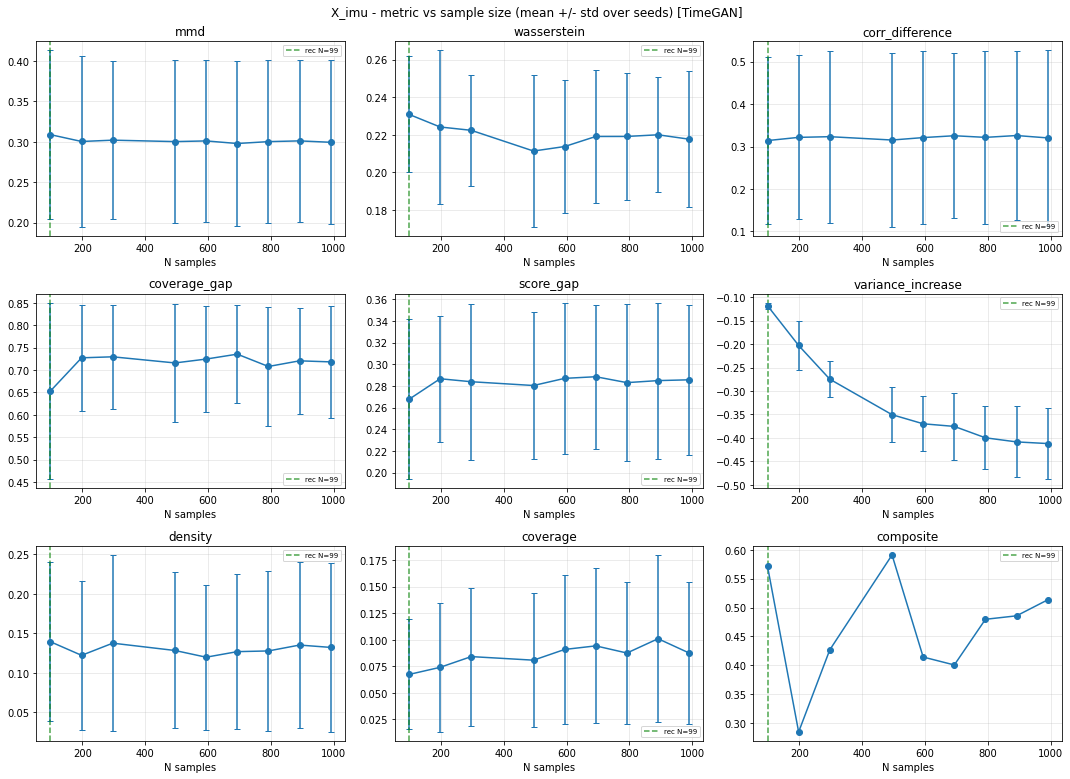

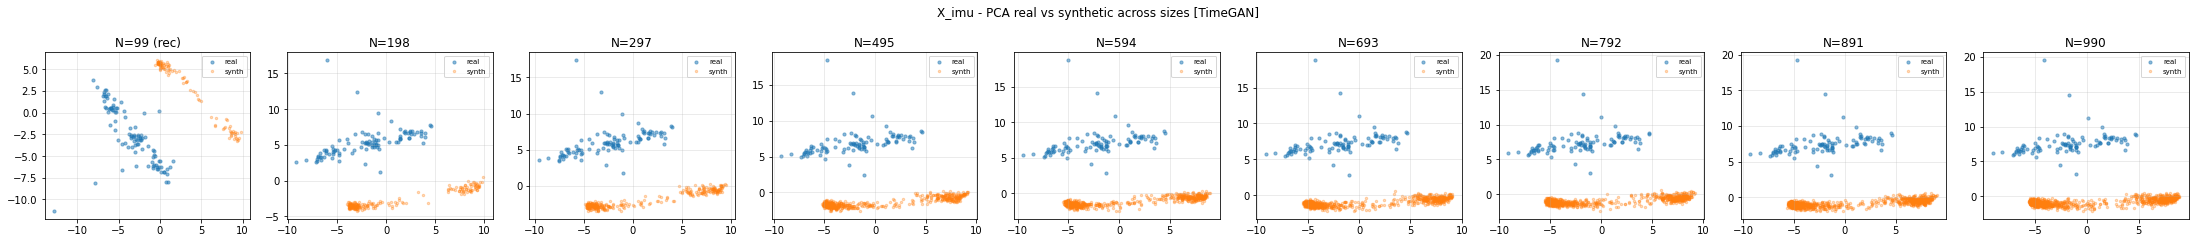

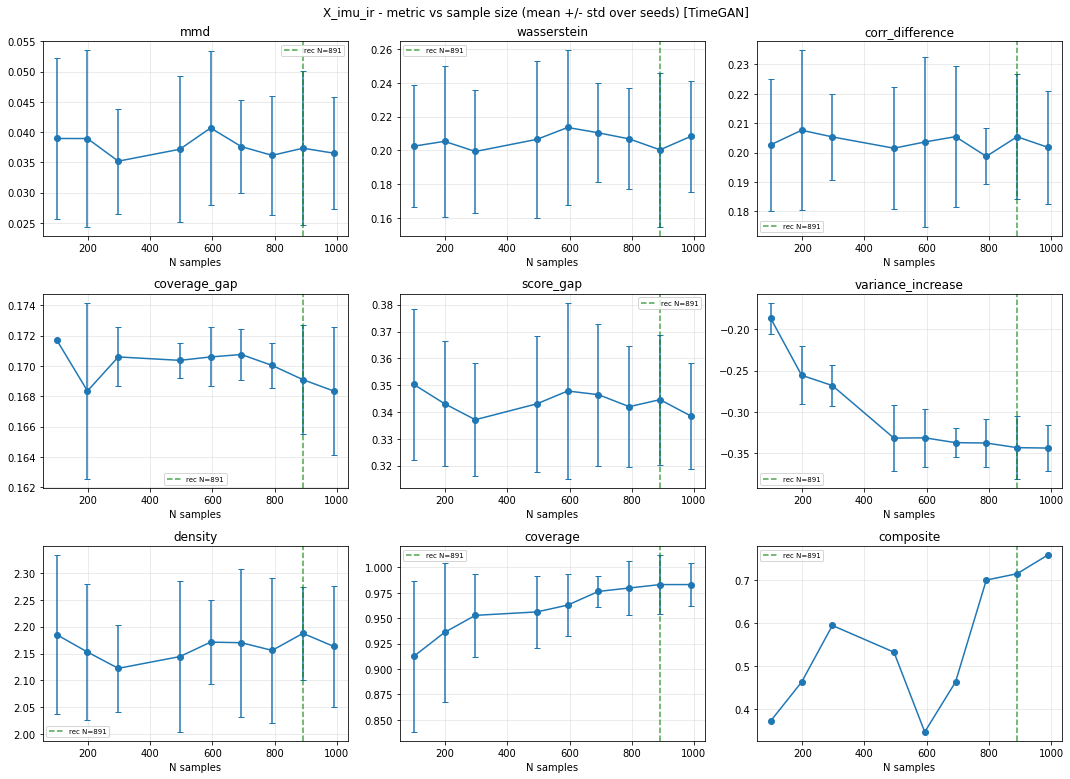

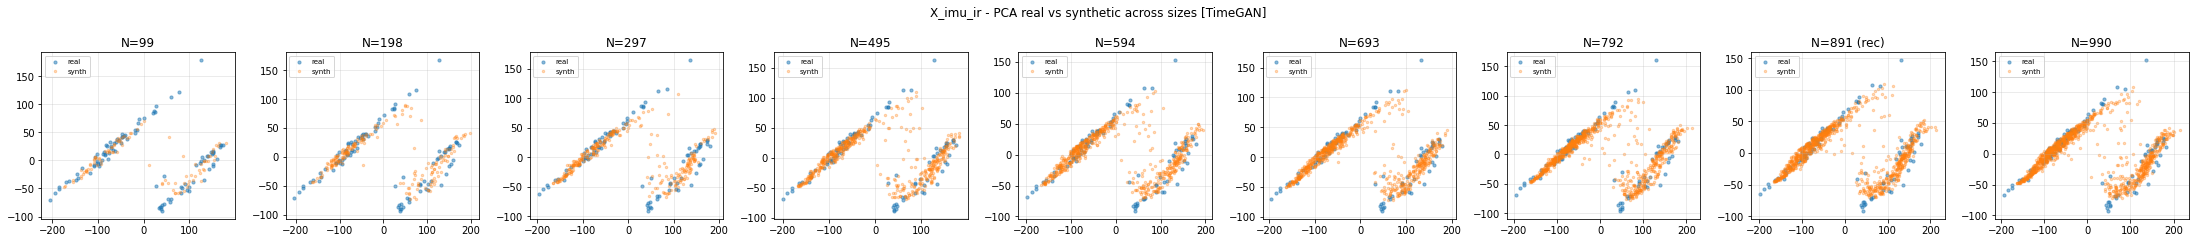

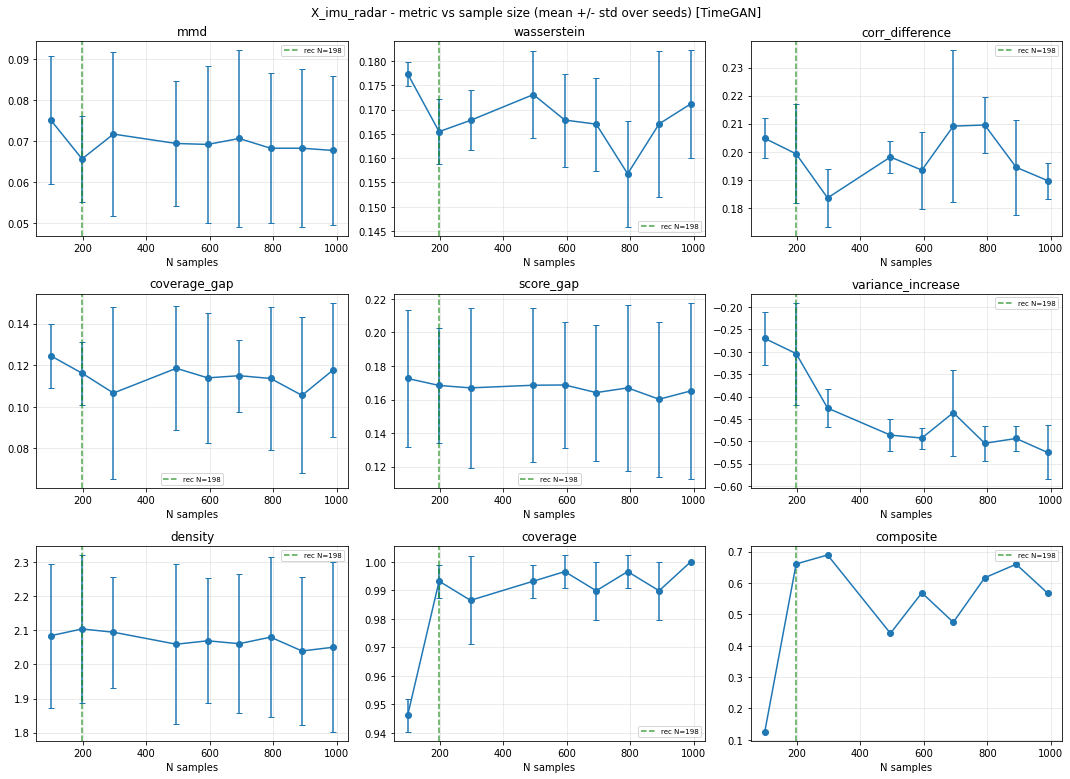

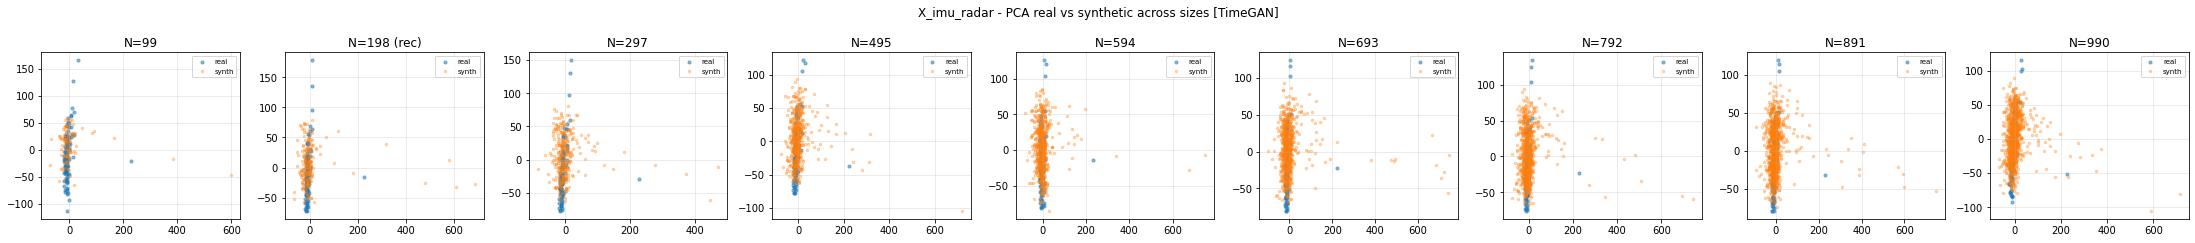

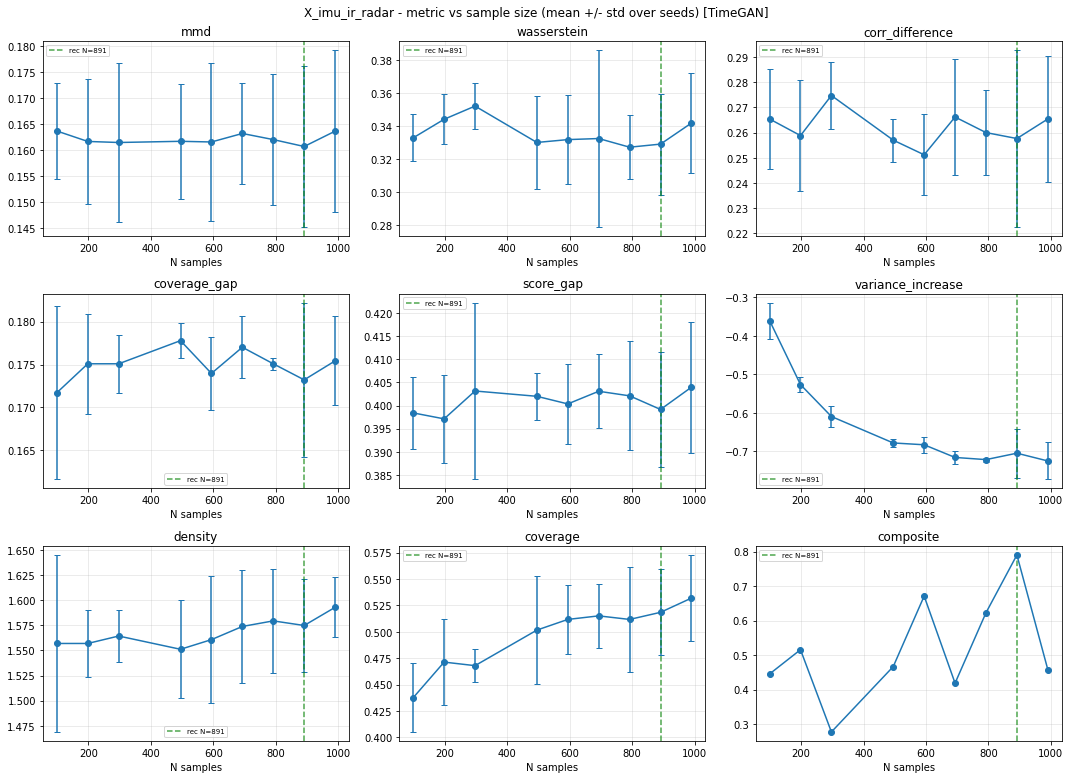

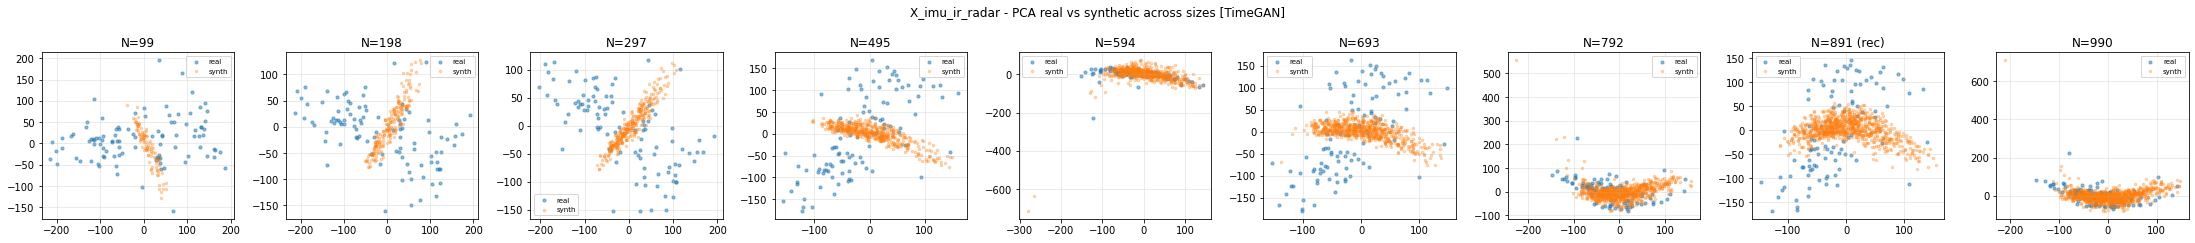

In [13]:
def plot_curves(name):
    sub=AGG[AGG.dataset==name].sort_values("N"); ss=AGG_STD[AGG_STD.dataset==name].sort_values("N")
    mets=["mmd","wasserstein","corr_difference","coverage_gap","score_gap","variance_increase","density","coverage","composite"]
    recN=REC[name]["N"]; fig,axes=plt.subplots(3,3,figsize=(15,11))
    for ax,mt in zip(axes.ravel(),mets):
        x=sub["N"].values; y=sub[mt].values
        yerr=ss[mt].values if mt in ss and mt!="composite" else None
        ax.errorbar(x,y,yerr=yerr,marker="o",capsize=3)
        ax.axvline(recN,color="green",ls="--",alpha=.7,label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} - metric vs sample size (mean +/- std over seeds) [TimeGAN]")
    fig.tight_layout(); fig.savefig(CFG.output_dir/f"{name}_curves.png",dpi=110); plt.show(); plt.close(fig)

def plot_pca(name):
    Re=EMB[name]["Re"]; syn=EMB[name]["synth"]; sizes=sorted(syn)
    fig,axes=plt.subplots(1,len(sizes),figsize=(3.4*len(sizes),3.4),squeeze=False)
    for j,N in enumerate(sizes):
        allp=np.vstack([Re,syn[N]]); p=PCA(2,random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T,s=10,alpha=.5,label="real")
        axes[0][j].scatter(*p[len(Re):].T,s=6,alpha=.3,label="synth")
        tag=" (rec)" if N==REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} - PCA real vs synthetic across sizes [TimeGAN]"); fig.tight_layout()
    fig.savefig(CFG.output_dir/f"{name}_pca.png",dpi=110); plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name)

## 13. Save synthetic data at the recommended size + package

Saves the generation chain (`generator` / `supervisor` / `recovery` `.keras`) plus the fitted `Prep`, so a synthetic set can be regenerated later as `Z -> G -> S -> R -> prep.inverse`.

In [14]:
import shutil
for name in RAW:
    tgan,prep,latent,_=MODELS[name]; recN=REC[name]["N"]
    set_seeds(CFG.seed)
    synth=generate(tgan,prep,recN,CFG,latent)
    d=CFG.output_dir/name; d.mkdir(parents=True,exist_ok=True)
    np.save(d/"synthetic_recommended.npy",synth)
    with open(d/"prep.pkl","wb") as f: pickle.dump(prep,f)
    tgan.generator.save(d/"generator.keras")
    tgan.supervisor.save(d/"supervisor.keras")
    tgan.recovery.save(d/"recovery.keras")
    pd.DataFrame([{"dataset":name,"recommended_N":recN,"multiplier":REC[name]["multiplier"],
                   "n_features":prep.F_full,"modeled_dim":prep.K}]).to_csv(d/"metadata.csv",index=False)
    print(f"  {name:16s} saved {synth.shape} at recommended N={recN}")
arch=shutil.make_archive(str(CFG.output_dir),"zip",root_dir=str(CFG.output_dir))
print("\nZipped ->",arch)

  X_imu            saved (99, 32, 3) at recommended N=99
  X_imu_ir         saved (891, 32, 771) at recommended N=891
  X_imu_radar      saved (198, 32, 1137) at recommended N=198
  X_imu_ir_radar   saved (891, 32, 1905) at recommended N=891

Zipped -> /voc/work/exp_3/timegan_size_study.zip


## Reading the results

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

Caveats: with ~99 real samples the TimeGAN learns a temporal manifold, so a "recommended size" tells you how
much to draw before returns vanish, not how to exceed the data-scarcity ceiling. The knee is averaged over
`n_seeds` splits; raise `n_seeds` to 5 for a tighter estimate. The real reference here is the full real set
(consistent across sizes); the study measures **relative** saturation, not absolute fidelity.

Because outputs mirror Experiment 2 exactly (`timegan_size_study/cross_dataset_summary.csv` shares columns
with `vae_size_study/cross_dataset_summary.csv`), the two files can be diffed directly to compare the VAE
and TimeGAN augmenters per dataset. TimeGAN is heavier to train (3 phases x GRUs on CPU): for a quick smoke
test set `n_seeds=1` and small `embedding/supervised/joint_epochs` before the full run.